## Building probabaility rank a matrix and seeing how it does with ARI
##### With this trial we aim to gather ground-truth blobs from the sklearn datasets, then we will add random gaussian noise to each of these points to simulate our observed blobs, using these observed blobs we will run a Monte Carlo simulation to then compare it to our ground-truth blobs using ARI 

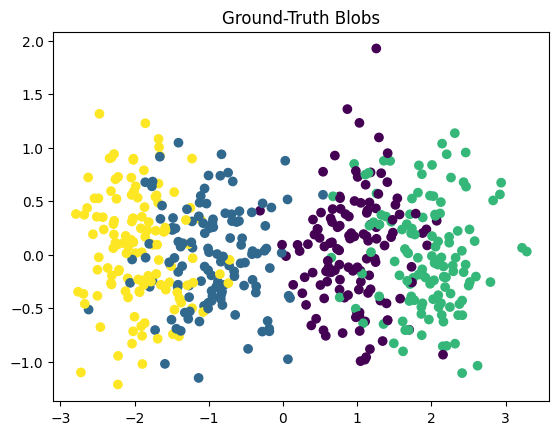

In [16]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, true_labels = make_blobs(
    n_samples = 500,
    centers = [(1, 0), (-1, 0), (2, 0), (-2, 0)],
    cluster_std = 0.5,
    random_state = 42
)

plt.scatter(X[:,0], X[:,1], c=true_labels, cmap='viridis')
plt.title("Ground-Truth Blobs")
plt.show ()

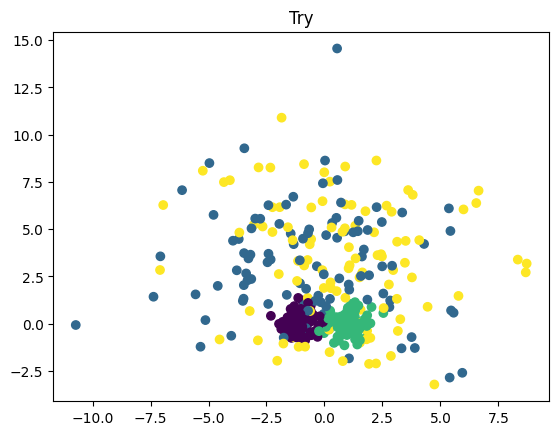

In [15]:
centers     = [[-1.0, 0.0], [-1.0, 3.0], [1.0, 0.0], [1.0, 3.0]]
cluster_std = [0.5, 3.0, 0.5, 3.0] 

n_per_comp = [100, 100, 100, 100]   

Y, raw_labels = make_blobs(
    n_samples    = n_per_comp,
    centers      = centers,
    cluster_std  = cluster_std,
    random_state = 42
    )

plt.scatter(Y[:,0], Y[:,1], c=raw_labels, cmap='viridis')
plt.title("Try")
plt.show ()

### Now we simulate a noise model 
##### We do this by adding random gaussian noise to each point of X simulating our observed X, which is what we will use for our Monte Carlo simulation

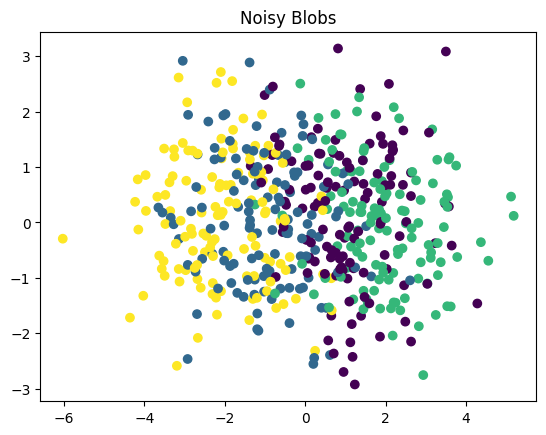

In [172]:
import numpy as np

std = 1.0
X_obs = X + np.random.normal(scale=std, size=X.shape)

plt.scatter(X_obs[:,0], X_obs[:,1], c=true_labels, cmap="viridis")
plt.title("Noisy Blobs")
plt.show()

### With this noise model we can run a Monte Carlo simulation to build our probability rank matrix
- Each entry in the first probability rank matrix ("matrix") is "probability that there are at least k neighbours closer to i than j is close to i"
- Each entry in the second probabaility rank matrix ("matrix_2") is "probability that j is in i's k nearest neigbours"

In [173]:
n, _ = X.shape # we have _ because we only care about our number of noisy datapoints
sims = 1000 # number of monte carlo sims
k = 5 # k-nearest neighbours

matrix = np.zeros((n, n), dtype=int)

for t in range(sims):

    X_obs = X + np.random.normal(scale=std, size=X.shape) # making the noisy points every time the sim is ran

    x = np.linalg.norm(X_obs[:,None,:] - X_obs[None,:,:], axis=2) # euclidian norm of the distance between i and j

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            num_closer = (x[i] < x[i, j]).sum() 
            if num_closer - 1 >= k:  
                matrix[i, j] += 1

M = matrix/sims # normalize matrix to get the average of every M[i, j] (which is the proabability of at least k neighbours being closer to i than j is)

In [174]:
matrix_2 = np.zeros((n, n), dtype=int)

for t in range(sims):

    X_obs = X + np.random.normal(scale=std, size=X.shape) # making the noisy points every time the sim is ran

    x = np.linalg.norm(X_obs[:,None,:] - X_obs[None,:,:], axis=2) # euclidian norm of the distance between i and j

    sorted_distances = np.argsort(x, axis=1)

    for f in range(n):
        knn = sorted_distances[f, 1:k+1]
        matrix_2[f, knn] += 1

M_2 = matrix_2/sims

### Running HDBSCAN with our probability rank matrix, and evaluating perfromance with ARI (Adjusted Rand Index)

In [175]:
from hdbscan import HDBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from fast_hdbscan.boruvka import sample_weight_core_distance

X_obs_fixed = X + np.random.normal(scale=std, size=X.shape)

nbrs = NearestNeighbors(n_neighbors=n).fit(X_obs_fixed)
distances, neighbors = nbrs.kneighbors(X_obs_fixed)

core_dist_unc = np.zeros(n, dtype=float)

for i in range(n):
    total = 0.0
    for idx in range(distances.shape[1]):
        j = neighbors[i, idx]
        if j == i:
            continue
        total += M[i, j]
        if total >= k:
            core_dist_unc[i] = distances[i, idx]
            break
    else:
        core_dist_unc[i] = distances[i, -1]

d_obs = np.linalg.norm(
    X_obs_fixed[:, None, :] - X_obs_fixed[None, :, :],
    axis=2
)

cd_i = core_dist_unc[:, None]   
cd_j = core_dist_unc[None, :]

assert cd_i.shape == (n, 1) and cd_j.shape == (1, n)

mutual = np.maximum(np.maximum(cd_i, cd_j), d_obs)

clusterer = HDBSCAN(
    metric='precomputed',     
    min_samples=k,
    min_cluster_size=k
)

pred_labels = clusterer.fit_predict(mutual)

ari = adjusted_rand_score(labels_true=true_labels, labels_pred=pred_labels)
print("ARI (uncertainty-aware):", ari)

ARI (uncertainty-aware): 0.006105120246615588


In [176]:
core_dist_unc_2 = np.zeros(n, dtype=float)

for i in range(n):
    total_2 = 0.0
    for idx in range(distances.shape[1]):
        j = neighbors[i, idx]
        if j == i:
            continue
        total_2 += M_2[i, j]
        if total_2 >= k:                 
            core_dist_unc_2[i] = distances[i, idx]
            break
    else:
        core_dist_unc_2[i] = distances[i, -1]

cd_i_2 = core_dist_unc_2[:, None]    
cd_j_2 = core_dist_unc_2[None, :]

assert cd_i_2.shape == (n, 1) and cd_j_2.shape == (1, n)

mutual_2 = np.maximum(np.maximum(cd_i_2, cd_j_2), d_obs) 

clusterer_2 = HDBSCAN(
    metric='precomputed',
    min_samples=k,
    min_cluster_size=k
)

pred_labels_2 = clusterer_2.fit_predict(mutual_2)

ari_2 = adjusted_rand_score(true_labels, pred_labels_2)
print("ARI (uncertainty-aware, variant 2):", ari_2)

ARI (uncertainty-aware, variant 2): 0.0
